In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Part 1

## Task 1

In [ ]:
np.random.seed(42)  # for reproducibility
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
], dtype=float)

n_women = 1000
X0 = 0        
n_states = P.shape[0]
DEAD = n_states - 1  

def sim_cancer_markov_until_all_dead(P, n_women, X0=0):
    current = np.full(n_women, X0, dtype=int)
    history = [current.copy()]

    while not np.all(current == DEAD):
        next_state = np.array([
            np.random.choice(P.shape[0], p=P[current[w]])
            for w in range(n_women)
        ])
        # Once dead, stay dead
        current = np.where(current == DEAD, DEAD, next_state)
        history.append(current.copy())

    return np.array(history).T  # shape: (n_women, T+1)

states_over_time = sim_cancer_markov_until_all_dead(P, n_women, X0)
T = states_over_time.shape[1] - 1
print(f"All {n_women} women reached Dead state after {T} time steps.")


All 1000 women reached Dead state after 1296 time steps.


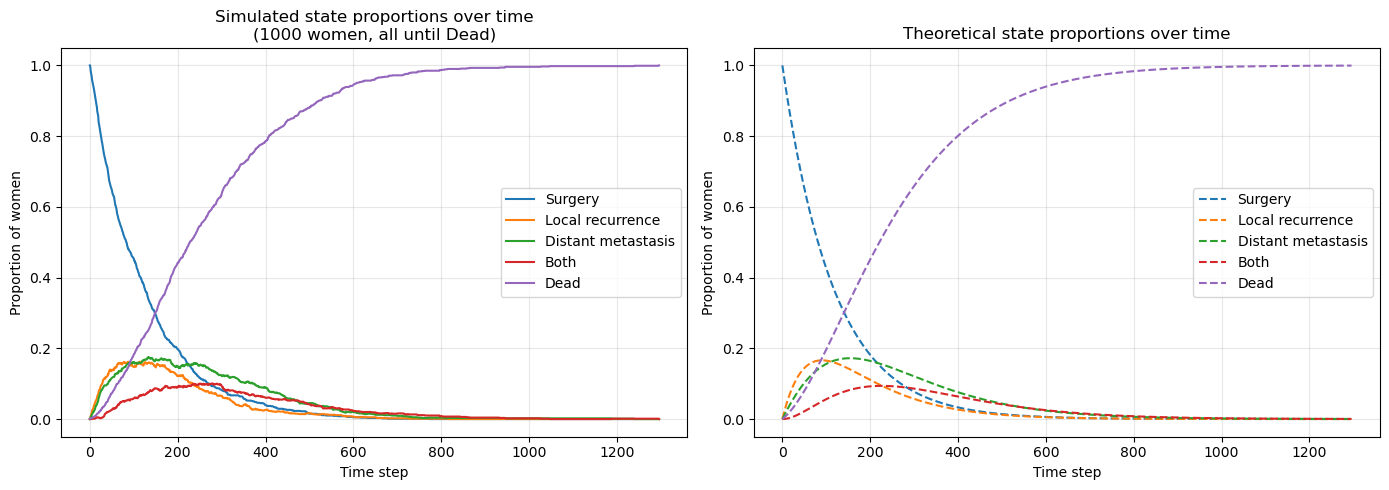

In [ ]:
np.random.seed(42)  
state_labels = ["Surgery", "Local recurrence", "Distant metastasis", "Both", "Dead"]

# Simulated proportions: fraction of women in each state at each time step
proportions = np.zeros((T + 1, n_states))
for t in range(T + 1):
    for s in range(n_states):
        proportions[t, s] = np.sum(states_over_time[:, t] == s) / n_women

# Theoretical proportions via matrix power: pi(t) = pi(0) @ P^t (from project beskrivelse)
pi = np.zeros((T + 1, n_states))
pi[0, X0] = 1.0
Pt = np.eye(n_states)
for t in range(1, T + 1):
    Pt = Pt @ P
    pi[t] = pi[0] @ Pt

time = np.arange(T + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for s in range(n_states):
    axes[0].plot(time, proportions[:, s], label=state_labels[s])
axes[0].set_title(f"Simulated state proportions over time\n({n_women} women, all until Dead)")
axes[0].set_xlabel("Time (months)")
axes[0].set_ylabel("Proportion of women")
axes[0].legend(loc="center right")
axes[0].grid(True, alpha=0.3)

for s in range(n_states):
    axes[1].plot(time, pi[:, s], linestyle="--", label=state_labels[s])
axes[1].set_title("Theoretical state proportions over time")
axes[1].set_xlabel("Time (months)")
axes[1].set_ylabel("Proportion of women")
axes[1].legend(loc="center right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [70]:
# Proportion of women who ever enter state 1 (local recurrence)
ever_local = np.any((states_over_time == 1) | (states_over_time == 3), axis=1)
prob_local_recurrence = ever_local.mean() * 100
print(f"Proportion of women where cancer eventually reappears locally: {prob_local_recurrence:.2f}%")


Proportion of women where cancer eventually reappears locally: 71.50%


## Task 2

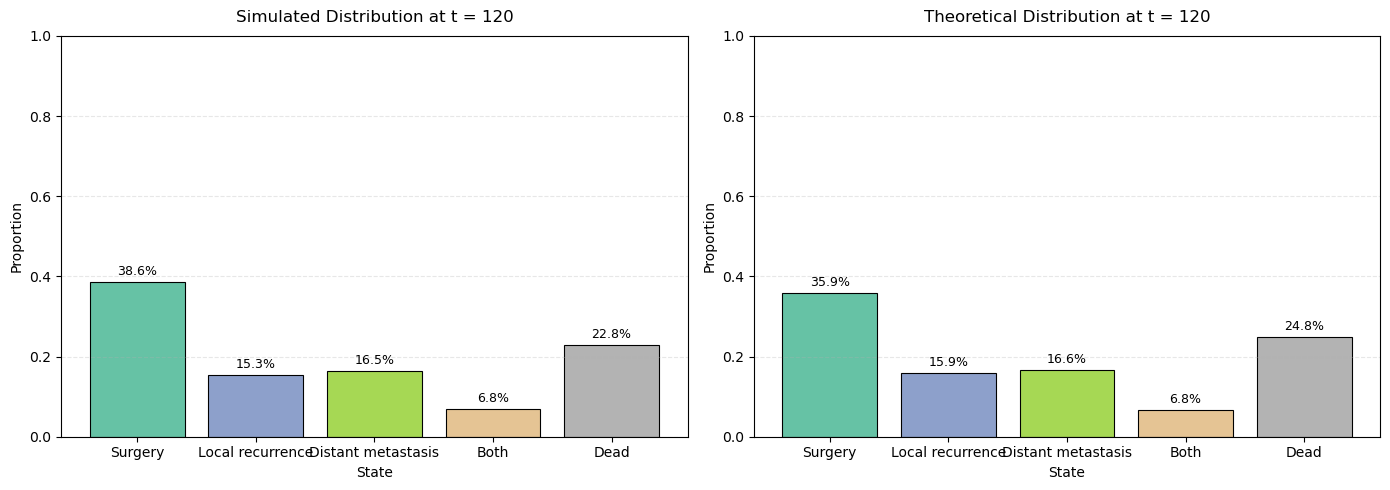

In [71]:
#distributions over states at t = 120
dist_120 = states_over_time[:, 120]
state_props_120 = np.bincount(dist_120, minlength=n_states) / n_women
colors = plt.cm.Set2(np.linspace(0, 1, n_states))

dist_120_ex = pi[120]  # Theoretical distribution at t=120 from matrix power
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simulated
bars_sim = axes[0].bar(
    range(n_states),
    state_props_120,
    tick_label=state_labels,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)
axes[0].set_title("Simulated Distribution at t = 120", pad=10)
axes[0].set_xlabel("State")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars_sim, state_props_120):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.1%}",
                 ha="center", va="bottom", fontsize=9)

# Theoretical
bars_th = axes[1].bar(
    range(n_states),
    dist_120_ex,
    tick_label=state_labels,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)
axes[1].set_title("Theoretical Distribution at t = 120", pad=10)
axes[1].set_xlabel("State")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars_th, dist_120_ex):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.1%}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Task 3